In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from datetime import timedelta
import statsmodels.formula.api as smf

from src.dynamic_pricing_data_loader import cargar_y_preparar_datos

In [2]:
def Get_Data():
    # Obtener el directorio de trabajo actual (ruta principal del proyecto).
    ruta_principal = os.getcwd()

    # Construir la ruta al archivo de configuración "config/config.json".
    config_path = os.path.join(ruta_principal, "config", "config.json")

    # Llamar a la función externa que carga y realiza preprocesamiento inicial.
    Frame = cargar_y_preparar_datos(config_path, ruta_principal)
    
    # Seleccionar solo las columnas relevantes para el análisis.
    D4NN = Frame[["PAX_SUBEN", 'FECHA_OPERACION','VENTA','ORIGEN', 'DESTINO','BOLETOS_VEND','TARIFA_BASE_TRAMO',
                 'HORA_SALIDA_CORRIDA']].copy()
    D4NN= D4NN[(D4NN['ORIGEN']=='MEXN') & (D4NN['DESTINO']== 'GDLJ')].copy()
    D4NN=D4NN.iloc[:-1]
    return D4NN

In [3]:
D4NN = Get_Data()

Memoria usada antes: 630.15 MB
Memoria usada después: 122.42 MB
Reducción: 80.6%


In [4]:
def Elasticity4_365Days(Df):
    D4NN= Df.copy()
    df_agg = D4NN.groupby(['FECHA_OPERACION']).agg(
        # Definición correcta de 3 nuevas columnas promediando cada original
        Promedio_Venta=('VENTA', 'mean'),
        Promedio_Pax=('PAX_SUBEN', 'mean'),
        Q_Pax=('PAX_SUBEN', 'count'),
        # Esta parte se ve bien
        Q_Boletos=('BOLETOS_VEND', 'count')
    ).reset_index()
    # 1. Encontrar la fecha máxima
    fecha_maxima = df_agg['FECHA_OPERACION'].max()
    # 2. Calcular el día anterior a la fecha máxima
    dia_anterior = fecha_maxima - timedelta(days=1)
    # 3. Calcular la fecha de inicio (365 días antes del día_anterior)
    fecha_inicio = dia_anterior - timedelta(days=364) # Para incluir 365 días, es decir, día_anterior y los 364 previos.
    # 4. Filtrar el DataFrame
    # Se incluyen todas las fechas en el rango [fecha_inicio, dia_anterior]
    Df_365 = df_agg[(df_agg['FECHA_OPERACION'] >= fecha_inicio) & 
                (df_agg['FECHA_OPERACION'] <= dia_anterior)].copy()
    
    plt.plot(Df_365['FECHA_OPERACION'], Df_365['Q_Boletos'])
    plt.show()
    
    Df_365['lnQ'] = np.log(df_agg['Q_Boletos'])
    Df_365['lnP'] = np.log(df_agg['Promedio_Venta'])
    
    model = smf.ols('lnQ ~ lnP', data=Df_365).fit()
    coeficientes = model.params
    b1 = model.params['lnP']
    print(f"El valor de la elasticidad es {b1}")
    return b1

In [5]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from datetime import timedelta

def Elasticity(Df):
    """
    Calcula elasticidades precio de la demanda (por hora, por día, por mes y por día de la semana)
    a partir de datos de ventas y boletos durante los últimos 365 días.

    Parámetros:
    -----------
    Df : pd.DataFrame
        DataFrame con al menos las columnas:
        - 'FECHA_OPERACION'
        - 'VENTA' (precio o ingreso por boleto)
        - 'BOLETOS_VEND'
        - 'HORA_SALIDA_CORRIDA' (hora de salida en formato datetime o entero)

    Retorna:
    --------
    dict con elasticidades:
        {'dia': valor,
         'hora_promedio': valor, 'hora_detalle': DataFrame,
         'mes_promedio': valor, 'mes_detalle': DataFrame,
         'semana_promedio': valor, 'semana_detalle': DataFrame}
    """

    D4NN = Df.copy()
    # ---  Filtrar últimos 365 días ---
    D4NN['FECHA_OPERACION'] = pd.to_datetime(D4NN['FECHA_OPERACION'])
    fecha_maxima = D4NN['FECHA_OPERACION'].max()
    dia_anterior = fecha_maxima - timedelta(days=1)
    fecha_inicio = dia_anterior - timedelta(days=364)
    D4NN = D4NN[(D4NN['FECHA_OPERACION'] >= fecha_inicio) &
                    (D4NN['FECHA_OPERACION'] <= dia_anterior)].copy()
    # ======================================================
    # === 1. Agregación diaria base =======================
    # ======================================================
    df_agg = D4NN.groupby(['FECHA_OPERACION']).agg(
        Promedio_Venta=('VENTA', 'mean'),
        Q_Boletos=('BOLETOS_VEND', 'count')
    ).reset_index()


    Df_365 = df_agg.copy()

    # --- 3. Visualización de demanda ---
    plt.figure(figsize=(10, 3))
    plt.plot(Df_365['FECHA_OPERACION'], Df_365['Q_Boletos'])
    plt.title("Boletos vendidos - últimos 365 días")
    plt.xlabel("Fecha")
    plt.ylabel("Boletos")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 4. Logs para la regresión diaria ---
    Df_365['lnQ'] = np.log(Df_365['Q_Boletos'])
    Df_365['lnP'] = np.log(Df_365['Promedio_Venta'])

    # --- 5. Modelo OLS diario ---
    model_dia = smf.ols('lnQ ~ lnP', data=Df_365).fit()
    elasticidad_dia = model_dia.params['lnP']
    print(f"Elasticidad (diaria): {elasticidad_dia:.3f}")

    # ======================================================
    # === 6. Agregación HORARIA ============================
    # ======================================================
    if np.issubdtype(D4NN['HORA_SALIDA_CORRIDA'].dtype, np.datetime64):
        D4NN['HORA_SALIDA_CORRIDA'] = D4NN['HORA_SALIDA_CORRIDA'].dt.hour
    D4NN['HORA_SALIDA_CORRIDA'] = np.where(D4NN['HORA_SALIDA_CORRIDA'] == 0, 24, D4NN['HORA_SALIDA_CORRIDA'])

    df_hora = D4NN.groupby(['FECHA_OPERACION', 'HORA_SALIDA_CORRIDA']).agg(
        PrecioPromedio=('VENTA', 'mean'),
        Q_Boletos=('BOLETOS_VEND', 'count')
    ).reset_index()

    df_hora = df_hora[(df_hora['PrecioPromedio'] > 0) & (df_hora['Q_Boletos'] > 0)].copy()
    df_hora['lnQ'] = np.log(df_hora['Q_Boletos'])
    df_hora['lnP'] = np.log(df_hora['PrecioPromedio'])

    # --- a) Elasticidad promedio por hora ---
    model_hora_global = smf.ols('lnQ ~ lnP + C(HORA_SALIDA_CORRIDA)', data=df_hora).fit()
    elasticidad_hora_promedio = model_hora_global.params['lnP']
    print(f"Elasticidad promedio (por hora, controlada): {elasticidad_hora_promedio:.3f}")

    # --- b) Elasticidad específica por hora ---
    resultados_hora = []
    for hora, data in df_hora.groupby('HORA_SALIDA_CORRIDA'):
        if len(data) > 10:
            m = smf.ols('lnQ ~ lnP', data=data).fit()
            resultados_hora.append({'Hora': hora, 'Elasticidad': m.params['lnP']})
    df_elasticidad_hora = pd.DataFrame(resultados_hora)

    # ======================================================
    # === 7. Agregación MENSUAL ============================
    # ======================================================
    D4NN['Mes'] = D4NN['FECHA_OPERACION'].dt.to_period('M')

    df_mes = D4NN.groupby(['Mes']).agg(
        PrecioPromedio=('VENTA', 'mean'),
        Q_Boletos=('BOLETOS_VEND', 'count')
    ).reset_index()

    df_mes['lnQ'] = np.log(df_mes['Q_Boletos'])
    df_mes['lnP'] = np.log(df_mes['PrecioPromedio'])

    # --- a) Elasticidad promedio mensual ---
    model_mes = smf.ols('lnQ ~ lnP', data=df_mes).fit()
    elasticidad_mes_promedio = model_mes.params['lnP']
    print(f"Elasticidad promedio (mensual): {elasticidad_mes_promedio:.3f}")

    # --- b) Elasticidad específica por mes ---
    resultados_mes = []
    for mes, data in D4NN.groupby('Mes'):
        data_agg = data.groupby('FECHA_OPERACION').agg(
            PrecioPromedio=('VENTA', 'mean'),
            Q_Boletos=('BOLETOS_VEND', 'count')
        ).reset_index()
        if len(data_agg) > 10:
            data_agg['lnQ'] = np.log(data_agg['Q_Boletos'])
            data_agg['lnP'] = np.log(data_agg['PrecioPromedio'])
            m = smf.ols('lnQ ~ lnP', data=data_agg).fit()
            resultados_mes.append({'Mes': str(mes), 'Elasticidad': m.params['lnP']})
    df_elasticidad_mes = pd.DataFrame(resultados_mes)

    # ======================================================
    # === 8. Agregación DÍA DE LA SEMANA ==================
    # ======================================================
    D4NN['DiaSemana'] = D4NN['FECHA_OPERACION'].dt.day_name()

    df_semana = D4NN.groupby(['DiaSemana']).agg(
        PrecioPromedio=('VENTA', 'mean'),
        Q_Boletos=('BOLETOS_VEND', 'count')
    ).reset_index()
    df_semana['lnQ'] = np.log(df_semana['Q_Boletos'])
    df_semana['lnP'] = np.log(df_semana['PrecioPromedio'])

    # --- a) Elasticidad promedio semanal ---
    model_semana = smf.ols('lnQ ~ lnP', data=df_semana).fit()
    elasticidad_semana_promedio = model_semana.params['lnP']
    print(f"Elasticidad promedio (día de la semana): {elasticidad_semana_promedio:.3f}")

    # --- b) Elasticidad específica por día de la semana ---
    resultados_semana = []
    for dia, data in D4NN.groupby('DiaSemana'):
        data_agg = data.groupby('FECHA_OPERACION').agg(
            PrecioPromedio=('VENTA', 'mean'),
            Q_Boletos=('BOLETOS_VEND', 'count')
        ).reset_index()
        if len(data_agg) > 10:
            data_agg['lnQ'] = np.log(data_agg['Q_Boletos'])
            data_agg['lnP'] = np.log(data_agg['PrecioPromedio'])
            m = smf.ols('lnQ ~ lnP', data=data_agg).fit()
            resultados_semana.append({'DiaSemana': dia, 'Elasticidad': m.params['lnP']})
    df_elasticidad_semana = pd.DataFrame(resultados_semana)

    # ======================================================
    # === 9. GRÁFICAS COMPARATIVAS =========================
    # ======================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # --- Elasticidad por hora ---
    if not df_elasticidad_hora.empty:
        df_elasticidad_hora = df_elasticidad_hora.sort_values('Hora')
        axes[0].bar(df_elasticidad_hora['Hora'], df_elasticidad_hora['Elasticidad'], color='teal', alpha=0.7)
        axes[0].axhline(0, color='black', linewidth=0.8)
        axes[0].set_title('Elasticidad precio por hora')
        axes[0].set_xlabel('Hora de salida')
        axes[0].set_ylabel('Elasticidad')
        axes[0].grid(True, alpha=0.3)

    # --- Elasticidad por mes ---
    if not df_elasticidad_mes.empty:
        df_elasticidad_mes = df_elasticidad_mes.sort_values('Mes')
        axes[1].bar(df_elasticidad_mes['Mes'].astype(str), df_elasticidad_mes['Elasticidad'], color='teal', alpha=0.7)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title('Elasticidad precio por mes')
        axes[1].set_xlabel('Mes')
        axes[1].set_ylabel('Elasticidad')
        axes[1].tick_params(axis='x', rotation=90)
        axes[1].grid(True, alpha=0.3)

    # --- Elasticidad por día de la semana ---
    if not df_elasticidad_semana.empty:
        df_elasticidad_semana = df_elasticidad_semana.sort_values('DiaSemana')
        axes[2].bar(df_elasticidad_semana['DiaSemana'], df_elasticidad_semana['Elasticidad'], color='teal', alpha=0.7)
        axes[2].axhline(0, color='black', linewidth=0.8)
        axes[2].set_title('Elasticidad por día de la semana')
        axes[2].set_xlabel('Día')
        axes[2].set_ylabel('Elasticidad')
        axes[2].tick_params(axis='x', rotation=45)
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ======================================================
    # === 10. Resultados finales ===========================
    # ======================================================
    resultados = {
        'dia': elasticidad_dia,
        'hora_promedio': elasticidad_hora_promedio,
        'hora_detalle': df_elasticidad_hora,
        'mes_promedio': elasticidad_mes_promedio,
        'mes_detalle': df_elasticidad_mes,
        'semana_promedio': elasticidad_semana_promedio,
        'semana_detalle': df_elasticidad_semana
    }

    return resultados


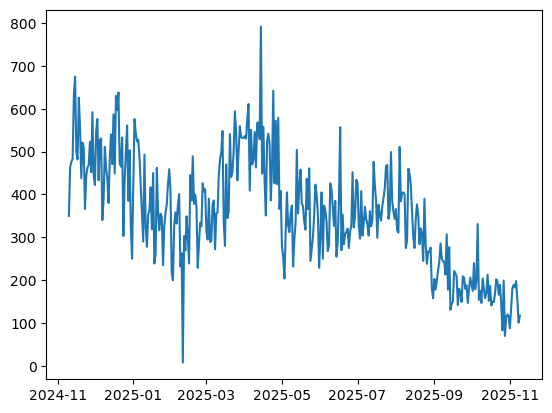

El valor de la elasticidad es -1.624770556215704


In [6]:
TBT= D4NN['TARIFA_BASE_TRAMO']
TBT= TBT.iloc[-10:-1].mean()
Elas= Elasticity4_365Days(D4NN)

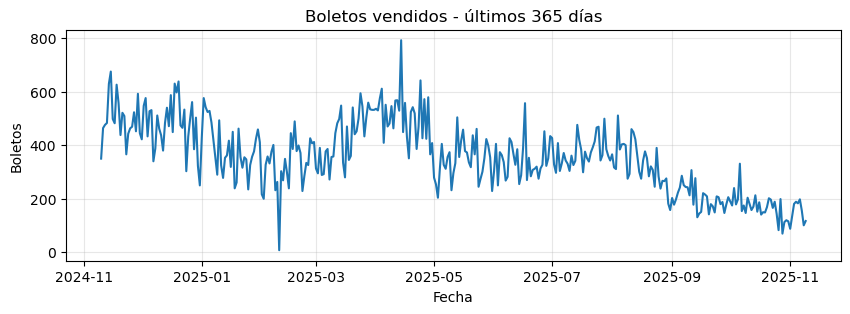

Elasticidad (diaria): -1.625
Elasticidad promedio (por hora, controlada): -0.159
Elasticidad promedio (mensual): -6.725
Elasticidad promedio (día de la semana): 1.216


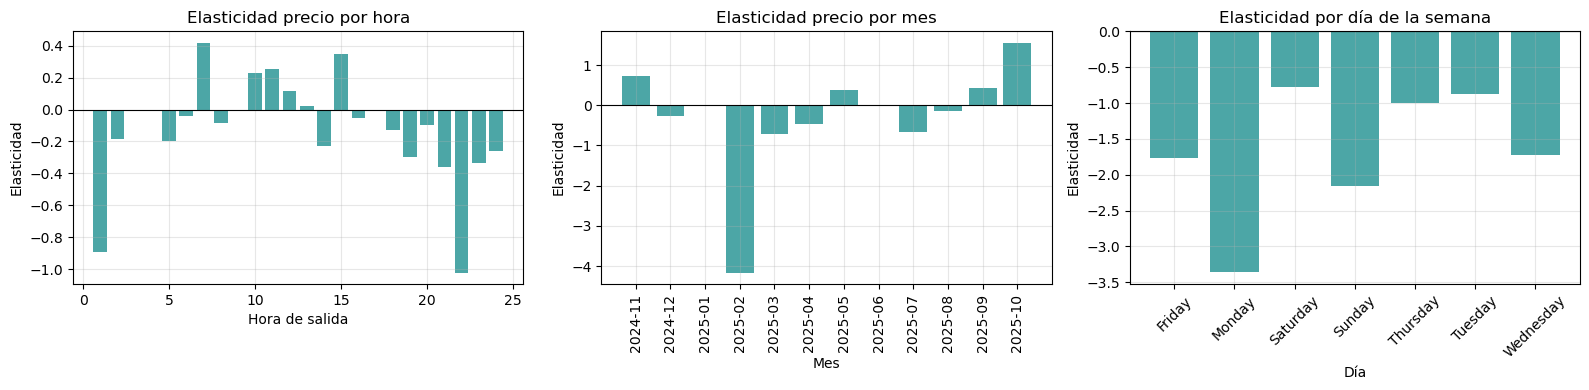

In [7]:
Elasticities= Elasticity(D4NN)


Para un viaje con una demanda base predicha de 1 boletos (a $1163.79):

--------------------------------------------------
  El precio óptimo recomendado es: $936.91
  Con este precio, el ingreso esperado se maximiza a: $1,233.67
--------------------------------------------------


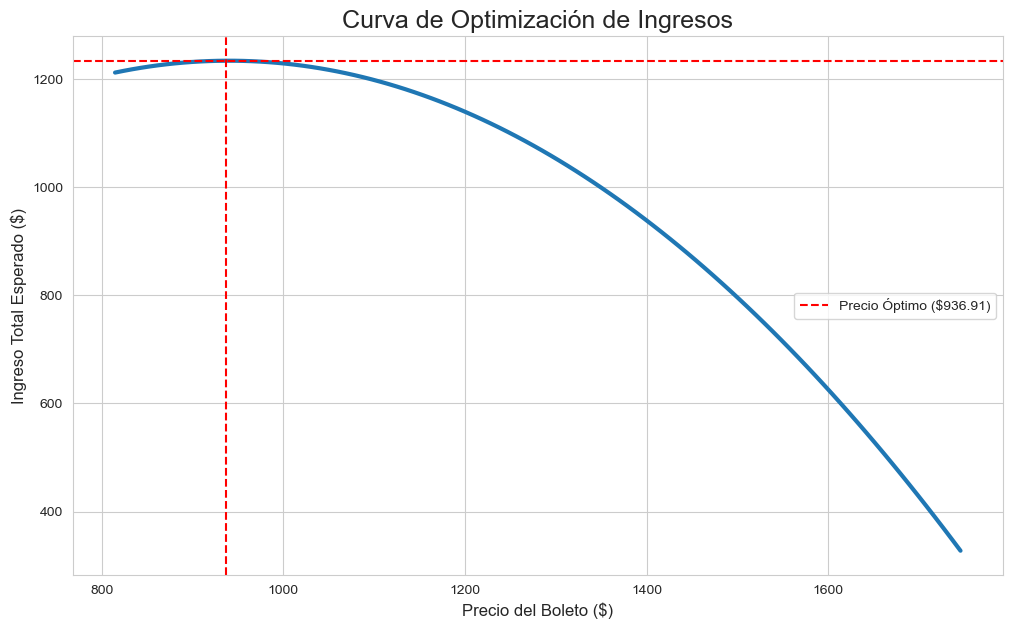

In [8]:
def encontrar_precio_optimo(demanda_base, tarifa_base, elasticidad, rango_precios=(0.7, 1.5), pasos=100):
    """
    Simula diferentes precios para encontrar el que maximiza el ingreso total.

    Args:
        demanda_base (float): La demanda predicha por el modelo de Fase 1 a la tarifa base.
        tarifa_base (float): El precio de referencia histórico para el viaje.
        elasticidad (float): El coeficiente de elasticidad precio de la demanda.
        rango_precios (tuple): Rango de precios a probar como multiplicador de la tarifa_base.
        pasos (int): Número de precios a probar en el rango.

    Returns:
        dict: Un diccionario con el precio óptimo, el ingreso máximo y datos para graficar.
    """
    # 1. Crear un rango de precios para probar
    precios_a_probar = np.linspace(
        tarifa_base * rango_precios[0],  # Precio mínimo
        tarifa_base * rango_precios[1],  # Precio máximo
        pasos
    )

    ingresos_esperados = []
    demandas_simuladas = []

    # 2. Simular la demanda y el ingreso para cada precio
    for nuevo_precio in precios_a_probar:
        # Calcular el cambio porcentual en el precio
        cambio_pct_precio = (nuevo_precio - tarifa_base) / tarifa_base

        # Usar la elasticidad para calcular el cambio porcentual en la demanda
        cambio_pct_demanda = elasticidad * cambio_pct_precio

        # Calcular la nueva demanda simulada
        nueva_demanda = demanda_base * (1 + cambio_pct_demanda)

        # Asegurarse de que la demanda no sea negativa
        if nueva_demanda < 0:
            nueva_demanda = 0

        demandas_simuladas.append(nueva_demanda)

        # Calcular el ingreso esperado para este precio
        ingreso = nuevo_precio * nueva_demanda
        ingresos_esperados.append(ingreso)

    # 3. Encontrar el precio que maximizó el ingreso
    ingreso_maximo = max(ingresos_esperados)
    indice_optimo = ingresos_esperados.index(ingreso_maximo)
    precio_optimo = precios_a_probar[indice_optimo]

    return {
        "precio_optimo": precio_optimo,
        "ingreso_maximo": ingreso_maximo,
        "datos_simulacion": pd.DataFrame({
            'precio_probado': precios_a_probar,
            'demanda_simulada': demandas_simuladas,
            'ingreso_esperado': ingresos_esperados
        })
    }


#T4E.MainElas()

demanda_predicha_base = 1
Tarifa= TBT
Elas= Elas
resultado_optimizacion = encontrar_precio_optimo(
    demanda_base=demanda_predicha_base,
    tarifa_base=TBT,
    elasticidad=Elas # El valor que obtuvimos en la Fase 2
)

precio_final = resultado_optimizacion['precio_optimo']
ingreso_final = resultado_optimizacion['ingreso_maximo']


# --- PASO E: MOSTRAR RESULTADOS Y GRÁFICO ---
print(f"\nPara un viaje con una demanda base predicha de {demanda_predicha_base:.0f} boletos (a ${TBT:.2f}):")
print("\n--------------------------------------------------")
print(f"  El precio óptimo recomendado es: ${precio_final:.2f}")
print(f"  Con este precio, el ingreso esperado se maximiza a: ${ingreso_final:,.2f}")
print("--------------------------------------------------")

# Graficar
df_simulacion = resultado_optimizacion['datos_simulacion']
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.lineplot(data=df_simulacion, x='precio_probado', y='ingreso_esperado', linewidth=3)
plt.axvline(x=precio_final, color='red', linestyle='--', label=f'Precio Óptimo (${precio_final:.2f})')
plt.axhline(y=ingreso_final, color='red', linestyle='--')
plt.title('Curva de Optimización de Ingresos', fontsize=18)
plt.xlabel('Precio del Boleto ($)', fontsize=12)
plt.ylabel('Ingreso Total Esperado ($)', fontsize=12)
plt.legend()
plt.show()